In [ ]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [18]:
# Load data
X_train = joblib.load("X_train.pkl")
X_test = joblib.load("X_test.pkl")
y_train = joblib.load("y_train.pkl")
y_test = joblib.load("y_test.pkl")

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

# Load models and predictions
model_paths = {
    "AdaBoost": "AdaBoost_model.pkl",
    "GradientBoosting": "GradientBoosting_model.pkl",
    "LDA": "LDA_model.pkl",
    "MLP": "MLP_model.pkl",
    "LogisticRegression": "LogisticRegression_model.pkl",
    "KNN": "KNN_model.pkl",
    "NaiveBayes": "NaiveBayes_model.pkl",
    "SVM": "SVM_model.pkl",
    "DecisionTree": "DecisionTree_model.pkl",
    "RandomForest": "RandomForest_model.pkl"
}

pred_paths = {
    "AdaBoost": "AdaBoost_pred.pkl",
    "GradientBoosting": "GradientBoosting_pred.pkl",
    "LDA": "LDA_pred.pkl",
    "MLP": "MLP_pred.pkl",
    "LogisticRegression": "LogisticRegression_pred.pkl",
    "KNN": "KNN_pred.pkl",
    "NaiveBayes": "NaiveBayes_pred.pkl",
    "SVM": "SVM_pred.pkl",
    "DecisionTree": "DecisionTree_pred.pkl",
    "RandomForest": "RandomForest_pred.pkl"
}

models = {}
predictions = {}
for name, path in model_paths.items():
    if os.path.exists(path):
        models[name] = joblib.load(path)
        print(f"{name} loaded successfully!")
    else:
        models[name] = None
        print(f"{name} chưa có model")

for name, path in pred_paths.items():
    if os.path.exists(path):
        predictions[name] = joblib.load(path)
        print(f"{name} predictions loaded successfully!")
    else:
        predictions[name] = None
        print(f"{name} chưa có predictions")

print("Models and predictions loaded successfully!")

X_test shape: (412, 4)
y_test shape: (412,)
X_train shape: (960, 4)
y_train shape: (960,)
AdaBoost loaded successfully!
GradientBoosting loaded successfully!
LDA loaded successfully!
MLP loaded successfully!
LogisticRegression loaded successfully!
KNN loaded successfully!
NaiveBayes loaded successfully!
SVM loaded successfully!
DecisionTree loaded successfully!
RandomForest loaded successfully!
AdaBoost predictions loaded successfully!
GradientBoosting predictions loaded successfully!
LDA predictions loaded successfully!
MLP predictions loaded successfully!
LogisticRegression predictions loaded successfully!
KNN predictions loaded successfully!
NaiveBayes predictions loaded successfully!
SVM predictions loaded successfully!
DecisionTree predictions loaded successfully!
RandomForest predictions loaded successfully!
Models and predictions loaded successfully!



=== AdaBoost ===
Accuracy : 1.00
Precision: 1.00
Recall   : 0.99
F1-score : 1.00

=== GradientBoosting ===
Accuracy : 1.00
Precision: 1.00
Recall   : 0.99
F1-score : 1.00

=== LDA ===
Accuracy : 0.98
Precision: 0.96
Recall   : 1.00
F1-score : 0.98

=== MLP ===
Accuracy : 1.00
Precision: 1.00
Recall   : 1.00
F1-score : 1.00

=== LogisticRegression ===
Accuracy : 0.98
Precision: 0.97
Recall   : 0.99
F1-score : 0.98

=== KNN ===
Accuracy : 1.00
Precision: 1.00
Recall   : 1.00
F1-score : 1.00

=== NaiveBayes ===
Accuracy : 0.84
Precision: 0.86
Recall   : 0.75
F1-score : 0.80

=== SVM ===
Accuracy : 1.00
Precision: 1.00
Recall   : 1.00
F1-score : 1.00

=== DecisionTree ===
Accuracy : 0.98
Precision: 0.99
Recall   : 0.97
F1-score : 0.98

=== RandomForest ===
Accuracy : 1.00
Precision: 1.00
Recall   : 0.99
F1-score : 1.00


,Model,Accuracy,Precision,Recall,F1
5,KNN,1.0000,1.0000,1.0000,1.0000
3,MLP,1.0000,1.0000,1.0000,1.0000
7,SVM,1.0000,1.0000,1.0000,1.0000
0,AdaBoost,0.9976,1.0000,0.9945,0.9973
1,GradientBoosting,0.9976,1.0000,0.9945,0.9973
9,RandomForest,0.9976,1.0000,0.9945,0.9973
2,LDA,0.9806,0.9581,1.0000,0.9786
4,LogisticRegression,0.9806,0.9679,0.9891,0.9784
8,DecisionTree,0.9806,0.9888,0.9672,0.9779
6,NaiveBayes,0.8374,0.8625,0.7541,0.8047


<Figure size 1200x600 with 0 Axes>

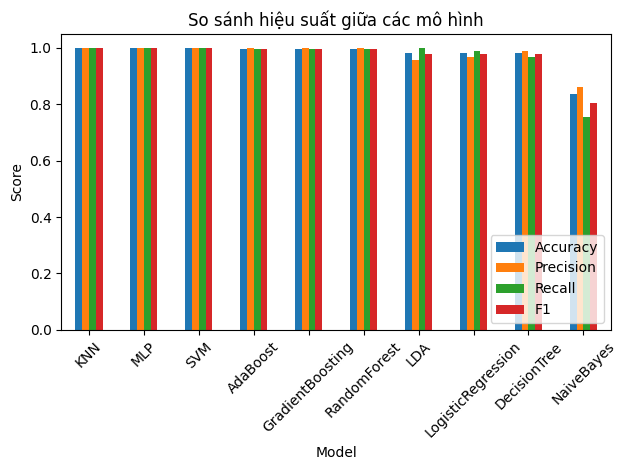

In [19]:
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='binary')
    rec = recall_score(y_true, y_pred, average='binary')
    f1 = f1_score(y_true, y_pred, average='binary')
    
    print(f"\n=== {model_name} ===")
    print(f"Accuracy : {acc:.2f}")
    print(f"Precision: {prec:.2f}")
    print(f"Recall   : {rec:.2f}")
    print(f"F1-score : {f1:.2f}")
    
    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1
    }

results = []
for name, y_pred in predictions.items():
    if y_pred is not None:
        results.append(evaluate_model(y_test, y_pred, name))

df_results = pd.DataFrame(results).sort_values(by='F1', ascending=False)
display(df_results.round(4))

# Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 6))
df_results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1']].plot(kind='bar')
plt.title('So sánh hiệu suất giữa các mô hình')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()